# Задание 7: CpG islands детектор

Реализуем поиск CpG-островков по критериям Гардинера-Гардена.  
Критерии из семинара: $R(CG) > 0.6$ и $GC\% > 50\%$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

## Загружаем первые 100 000 нт 

In [8]:
record = next(SeqIO.parse("GCA_029856635.1_ASM2985663v1_genomic.fna", "fasta"))
seq = str(record.seq[:100_000]).upper()

print(f"Загружено: {len(seq)} нт")

Загружено: 37163 нт


## 1. Функция compute_cpg_ratio

$$R(CG) = \frac{P(CG)}{P(C) \times P(G)}$$

In [9]:
def compute_cpg_ratio(window):
    """
    Вычисляет R(CG) и GC% для окна последовательности.
    Возвращает словарь с R_CG, GC_pct, valid.
    """
    n = len(window)
    acgt = sum(window.count(c) for c in 'ACGT')
    if acgt < 2:
        return {'R_CG': 0.0, 'GC_pct': 0.0, 'valid': False}

    count_C  = window.count('C')
    count_G  = window.count('G')
    count_CG = window.count('CG')

    P_C  = count_C / acgt
    P_G  = count_G / acgt
    P_CG = count_CG / (acgt - 1)

    GC_pct = (count_C + count_G) / acgt * 100

    if P_C * P_G == 0:
        R_CG = 0.0
    else:
        R_CG = P_CG / (P_C * P_G)

    return {'R_CG': R_CG, 'GC_pct': GC_pct, 'valid': True}

## 2–3. Сканирование скользящим окном 200 нт

In [10]:
WINDOW_SIZE = 200
R_THRESHOLD = 0.6
GC_THRESHOLD = 50.0

positions   = []
r_cg_values = []
is_island   = []

for i in range(len(seq) - WINDOW_SIZE + 1):
    window = seq[i:i + WINDOW_SIZE]
    result = compute_cpg_ratio(window)
    if result['valid']:
        positions.append(i)
        r_cg_values.append(result['R_CG'])
        is_island.append(result['R_CG'] > R_THRESHOLD and result['GC_pct'] > GC_THRESHOLD)

positions   = np.array(positions)
r_cg_values = np.array(r_cg_values)
is_island   = np.array(is_island)

print(f"Просканировано позиций: {len(positions)}")
print(f"Окон с R_CG > {R_THRESHOLD} и GC% > {GC_THRESHOLD}: {is_island.sum()}")

Просканировано позиций: 36964
Окон с R_CG > 0.6 и GC% > 50.0: 14


## Координаты CpG-островков

In [11]:
cpg_positions = positions[is_island]

# Мёрдж перекрывающихся окон в непрерывные регионы
islands = []
if len(cpg_positions) > 0:
    start = cpg_positions[0]
    end   = cpg_positions[0] + WINDOW_SIZE
    for pos in cpg_positions[1:]:
        if pos <= end:
            end = pos + WINDOW_SIZE
        else:
            islands.append((start, end))
            start = pos
            end   = pos + WINDOW_SIZE
    islands.append((start, end))

print(f"CpG-островков найдено: {len(islands)}")
for i, (s, e) in enumerate(islands):
    print(f"  Островок {i+1}: {s} - {e}  (длина {e-s} нт)")

CpG-островков найдено: 1
  Островок 1: 17071 - 17287  (длина 216 нт)


## 4. Визуализация

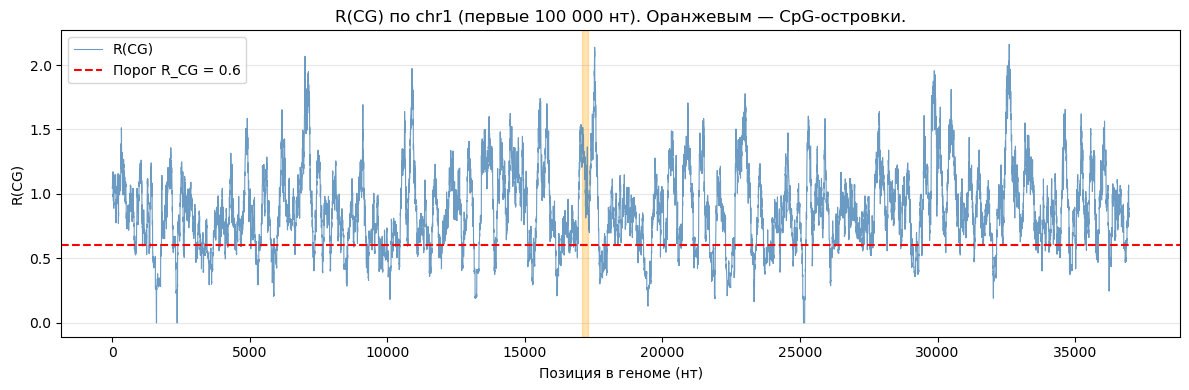

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(positions, r_cg_values, color='steelblue', linewidth=0.8, alpha=0.8, label='R(CG)')
plt.axhline(y=R_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Порог R_CG = {R_THRESHOLD}')

for s, e in islands:
    plt.axvspan(s, e, color='orange', alpha=0.3)

plt.xlabel("Позиция в геноме (нт)")
plt.ylabel("R(CG)")
plt.title("R(CG) по chr1 (первые 100 000 нт). Оранжевым — CpG-островки.")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("cpg_islands.png", dpi=150)
plt.show()